# MedViz WamUp - Part 1

### Authors
- Pol Roca
- Adrià Lozano
- Lluna Clavera

## Introduction to SimpleITK

### Overview

SimpleITK is a library (for multiple programming languages) focused on multi-dimensional image analysis. As medical imaging needs requires to process and analyse multi-dimensinal image data (mostly 3D), we can make use of this library for the required tasks.

SimpleITK is a simplified interface to the Insight Segmentation and Registration Toolkit (ITK), which makes it easier to work with.

---
⚠️​
Comment by [Carles]: 
*In the last sentence "SimpleITK is a simplified interface to the Insight Segmentation and Registration Toolkit (ITK)...", you make it sound like SimpleITK stands for Insight Segmentation and Registration Toolkit. This is not the case since it stands for Insight Toolkit. This does not affect this documentation but would be nice to clarify what the acronym stands for and what the ITK project does.*

```
SimpleITK is a simplified programming interface to the algorithms and data structures of the Insight Toolkit (ITK) for image analysis. It supports interfaces for multiple programming languages including C++, Python, R, Java, C#, Lua, Ruby and TCL
```
---

### Installation

The installation of SimpleITK is really simple, we can install it using pip install

In [ ]:
!pip install simpleitk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 18.7 MB/s eta 0:00:00


## Loading and Displaying images

### Loading Images

To load images, SimpleITK offers the funcion "ReadImage". SimpleITK supports multiple file extensions for images, but we are going to use the NIfTI extension (.nii)

After importing the image we can display multiple parameters of it, using SimpleITK functions.

**Note: To be able to load an image from Google Collab, you should drag and drop a NifTI file.**

In [1]:
import SimpleITK as sitk

image = sitk.ReadImage("./low_low_resolution.nii.gz", imageIO="NiftiImageIO")
print("\n--- Image Properties ---")
print(f"Size: {image.GetSize()}  (x, y, z)")
print(f"Spacing: {image.GetSpacing()}  (mm)")
print(f"Origin: {image.GetOrigin()}  (mm)")
print(f"Pixel Type: {image.GetPixelIDValue()} ({image.GetPixelIDTypeAsString()})")



--- Image Properties ---
Size: (128, 128, 100)  (x, y, z)
Spacing: (2.6171875, 2.6171875, 4.0)  (mm)
Origin: (0.0, 0.0, 0.0)  (mm)
Pixel Type: 4 (32-bit signed integer)


---
⚠️​
Comment by [Carles]: 

*would be nice to clarify what type is the object **image=sitk.ReadImage(...)**? is it a numpy array or a sitk class? or something else?*

*Good job showing that this sitk.Image object, which is a multi-dimensional image container that can store scalar, vector, or complex pixel data, has some methods provided by sitk*

---

### Display images

To display images we need to use an external library, in this case we are going to use matplotlib.

We are going to define a fuction to simplify the process of displaying an image. The funcion needs the image to be 2D, so we need to create slices before using it.

In [7]:
def show_image(img, title=''):
  image_np = sitk.GetArrayFromImage(img)

  plt.imshow(image_np, cmap='gray')
  plt.axis('off')
  plt.title(title)
  plt.show()

Slicing can be performed by using the [] python operator. We can set two coordinates to ":" and use the third coordinate to select the slice.

---
⚠️​
Comment by [Carles]: 

*The sentence "using the [] python operator" feels a bit vague and it is not accurate.*

*Slicing can be performed using the NumPy extended slicing syntax. SITK uses numpy under the hood so we are just manipulating np.array objects.* 

*!! Python native lists only support syntax obj[start:stop:step] while numpy supports obj[start:end, start:end, start:end]*

---

In [8]:
image_0 = image[:,:,0]
image_50 = image[:,:,50]
image_50_y = image[:,50,:]
image_50_x = image[50,:,:]

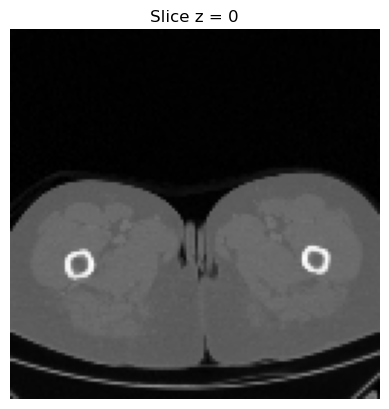

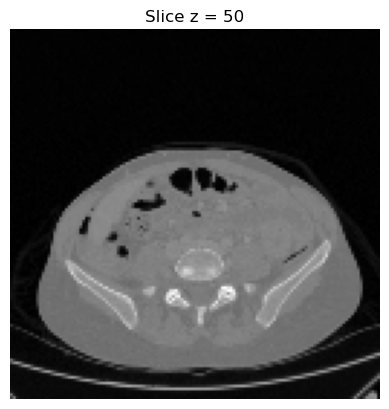

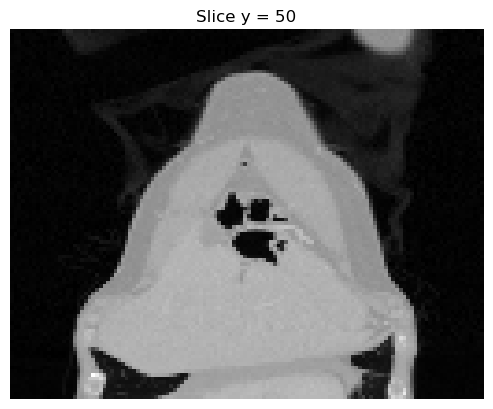

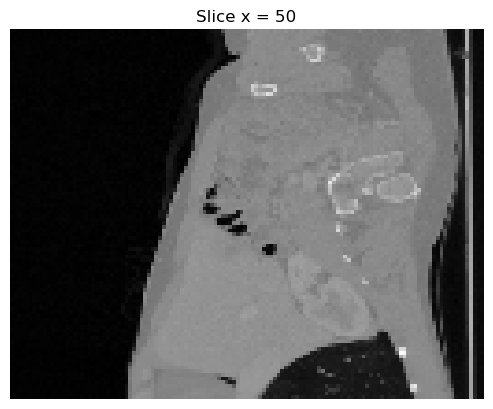

In [9]:
import matplotlib.pyplot as plt
import numpy as np


#z = 0
show_image(image_0, "Slice z = 0")

#z=50
show_image(image_50, "Slice z = 50")

#y = 50
show_image(image_50_y, "Slice y = 50")

#x = 50
show_image(image_50_x, "Slice x = 50")


## Basic Image Manipulation

### Resampling and Resizing


In order to resample and resize the image we are going to use the "ResampleImageFilter" class of SimpleITK, we also tested the "Resample" function, which also does the work, but uses a different syntax

---
⚠️​
Comment by [Carles]: 

Nothing to say here. Clear, concise and reusable.

---

In [5]:
def resample_img(itk_image, out_spacing, is_label=False):
    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))
        ]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)

    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

In [6]:
print(image.GetSpacing())

(2.6171875, 2.6171875, 4.0)


If we multiply the spacing by 4, we will divide the resolution by 4, as each voxel will represent a bigger chunk.

In [7]:
#Resample, 1/4 resolution
resampled_sitk_img = resample_img(image, out_spacing=[10.4, 10.4, 16.0], is_label=False)
#resampled_sitk_img = sitk.Resample(image, image.GetSize(), sitk.Transform(), sitk.sitkLinear, [3.0,3.0,4.2])

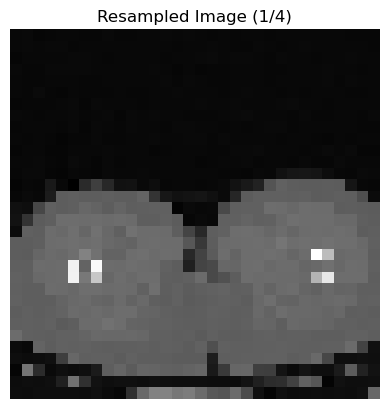

In [8]:
image_0 = resampled_sitk_img[:,:,0]
image_np = sitk.GetArrayFromImage(image_0)

show_image(image_0, "Resampled Image (1/4)")


### Cropping

To crop an image we can also us the python [] operator. Similarly to slicing, we can select only a slice of each coordinate so we get a cropped image as a result.

---
⚠️​
Comment by [Carles]: 

*just a reminder that we are working with numpy that behaves a bit different than python. It has more functionalityes such as the slicing syntax extension*

---

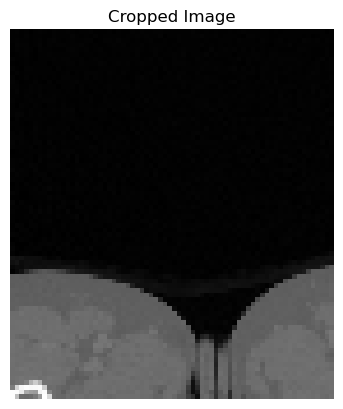

In [9]:
image_cropped = image[20:90,0:80,0]

show_image(image_cropped, "Cropped Image")

We can also use the "RegionOfInterest" function of SimpleITK to get the same result

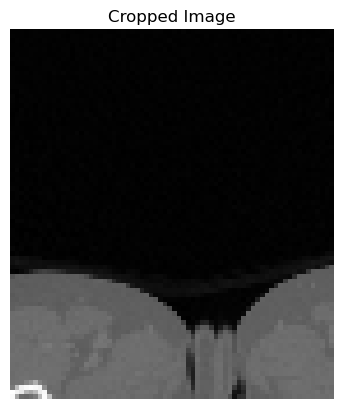

In [10]:
image_cropped2 = sitk.RegionOfInterest(image, size=[70,80,100], index=[20,0,0])
show_image(image_cropped2[:,:,1], "Cropped Image")

### Intensity Transformation


To make an intensity transformation we can simply use the "RescaleIntensityImageFIlter" class of the library, similarly to the "ResampleImageFilter" for the resampling.

We tried a couple of values to test the result.

---
⚠️​
Comment by [Carles]: 

*Would be nice a small carification of what RescaleIntensityImageFIlter is doing: It maps the input intensity range to a new range linearly.*

---

In [11]:
rescaleIntensity = sitk.RescaleIntensityImageFilter()
rescaleIntensity.SetOutputMaximum(3)
rescaleIntensity.SetOutputMinimum(1)

image_transformed_3_1 = rescaleIntensity.Execute(image)

rescaleIntensity.SetOutputMaximum(4)
rescaleIntensity.SetOutputMinimum(1)

image_transformed_4_1 = rescaleIntensity.Execute(image)

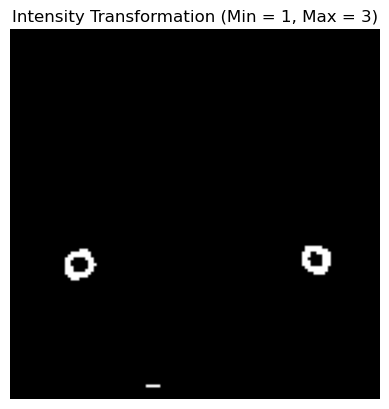

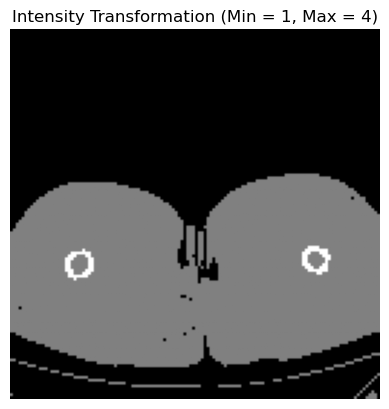

In [12]:

show_image(image_transformed_3_1[:,:,0], "Intensity Transformation (Min = 1, Max = 3)")
show_image(image_transformed_4_1[:,:,0], "Intensity Transformation (Min = 1, Max = 4)")


We can also use the "IntensityWindowing" and define both the output minimum and maximum and also define a window with its min and max values.

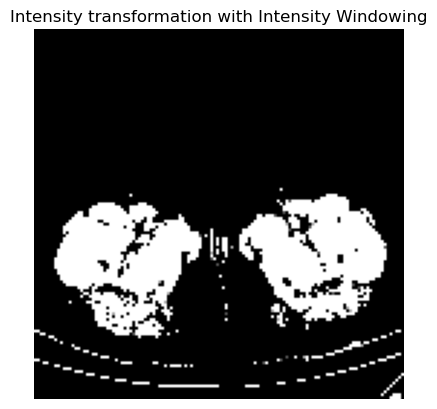

In [13]:
image_windowFilter = sitk.IntensityWindowing(image, 1, 4,3,12)
image_np = sitk.GetArrayFromImage(image_windowFilter[:,:,0])

show_image(image_windowFilter[:,:,0], "Intensity transformation with Intensity Windowing")

## Image Registration

Image registration consists on aligning two images using linear transformations (translations, rotations and scaling). To properly align the images, they have to come from the same source (or represent the same object), as aligning two compleatly different images will not make sense.

As we need two images of the same object, we can shift one image and then try to realign it using SimpleITK functions

---
⚠️​
Comment by [Carles]: 

*Cool to show the CheckerBoard functionality (I didn't know it existed). It seems a bit tricky to understand it visually, maybe because of the tailing size, not sure. It would be nice to also show some other overlaying method that does not glitch my brain.*

---

In [14]:
image = sitk.ReadImage("./low_low_resolution.nii.gz", imageIO="NiftiImageIO")

#Shift image
translation = [28.0, 15.0, 0.0]
transform = sitk.TranslationTransform(3, translation)

shifted_image = sitk.Resample(image, image, transform, sitk.sitkLinear, 0.0, image.GetPixelID())

After shifting the image, we can plot a checkerboard that shows both images at the same time to check that they are missaligned.

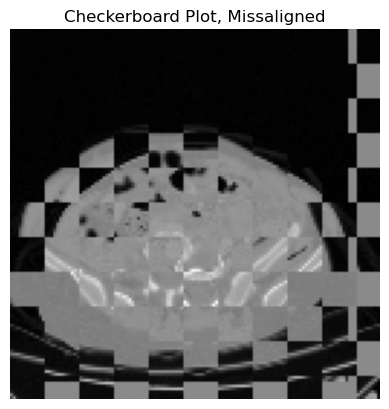

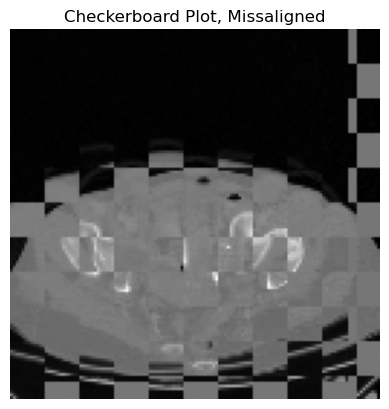

In [15]:
def show_checkerboard(img1, img2, title=''):
    checkerboard = sitk.CheckerBoard(img1, img2, [10, 10]) # 10-pixel squares
    show_image(checkerboard, title=title)

central_slice = image.GetSize()[2]//2
show_checkerboard(image[:,:,central_slice], shifted_image[:,:,central_slice], "Checkerboard Plot, Missaligned")
show_checkerboard(image[:,:,central_slice//2], shifted_image[:,:,central_slice//2], "Checkerboard Plot, Missaligned")

Using the "ImageRegistrationMethod" class of SimpleITK we can perform the registration to align the images. There are multiple ways to do the registration but we used Gradient Descent with Mean Squares as a metric

In [16]:
registration_method = sitk.ImageRegistrationMethod()
registration_method.SetMetricAsMeanSquares()
registration_method.SetOptimizerAsGradientDescent(learningRate=1.0, numberOfIterations=100,estimateLearningRate=registration_method.EachIteration)
registration_method.SetOptimizerScalesFromPhysicalShift()

registration_method.SetInitialTransform(sitk.TranslationTransform(image.GetDimension()))
registration_method.SetInterpolator(sitk.sitkLinear)

# Cast images to float32 before registration, as ImageRegistrationMethod typically requires float types
image_float = sitk.Cast(image, sitk.sitkFloat32)
shifted_image_float = sitk.Cast(shifted_image, sitk.sitkFloat32)

transform = registration_method.Execute(image_float, shifted_image_float)


Finally, we can check that the registration was succesful using plotting another checkerboard

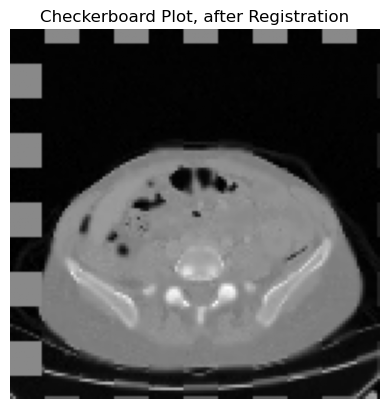

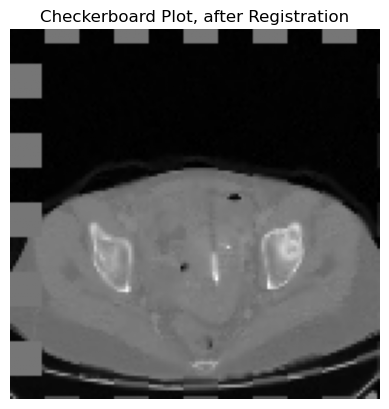

In [17]:

corrected_image = sitk.Resample(shifted_image, image, transform, sitk.sitkLinear, 0.0, shifted_image.GetPixelID())

#corrected_8bit = sitk.Cast(sitk.RescaleIntensity(corrected_image), sitk.sitkUInt8)
show_checkerboard(image[:,:,central_slice], corrected_image[:,:,central_slice], "Checkerboard Plot, after Registration")
show_checkerboard(image[:,:,central_slice//2], corrected_image[:,:,central_slice//2], "Checkerboard Plot, after Registration")

# MedViz WamUp - Part 2

## 5. Visualization Enhancement

In this section, we will explore different visualization techniques to better understand and analyze medical imaging data. We'll apply various color maps, create overlays, add annotations, and explore 3D rendering options.

### 5.1 Color Map Comparison

Different color maps can reveal different features in medical images. We'll compare several popular color maps to see how they affect our perception of the data.

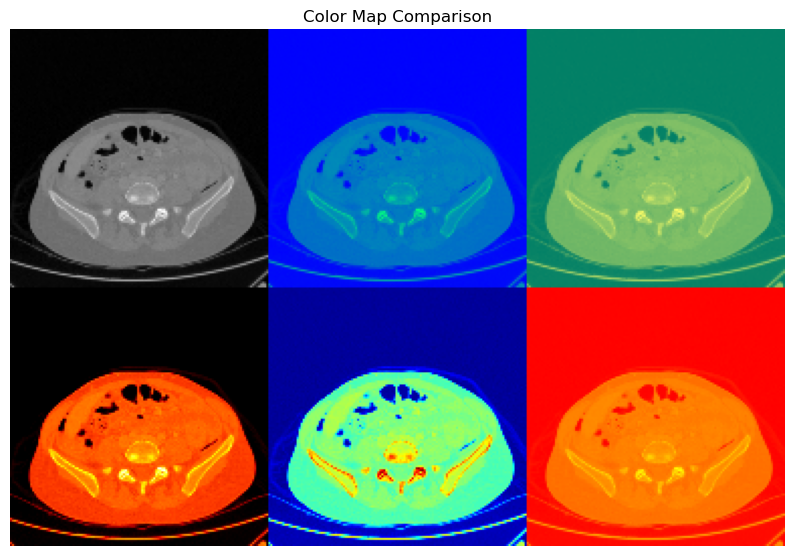

In [24]:
image = sitk.ReadImage("./low_low_resolution.nii.gz", imageIO="NiftiImageIO")

central_slice_idx = image.GetSize()[2] // 2
slice_2d = image[:, :, central_slice_idx]

colormap_filter = sitk.ScalarToRGBColormapImageFilter()

itk_colormaps = [
    sitk.ScalarToRGBColormapImageFilter.Grey,
    sitk.ScalarToRGBColormapImageFilter.Winter,
    sitk.ScalarToRGBColormapImageFilter.Summer,
    sitk.ScalarToRGBColormapImageFilter.Hot,
    sitk.ScalarToRGBColormapImageFilter.Jet,
    sitk.ScalarToRGBColormapImageFilter.Autumn
]

rgb_slices = []

for cmap in itk_colormaps:
    colormap_filter.SetColormap(cmap)
    rgb_image = colormap_filter.Execute(slice_2d)
    rgb_slices.append(rgb_image)

grid = sitk.Tile(rgb_slices, [3, 2])

grid_np = sitk.GetArrayFromImage(grid)

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(grid_np)
ax.set_title("Color Map Comparison")
ax.axis('off')

plt.show()

Each of the color map serves a purpose:
- Grey: Standard for medical imaging, preserves natural intensity relationships
- Winter: Cool blue-to-cyan gradient, good for temperature-like data
- Summer: Warm yellow-to-green gradient, highlights variations smoothly
- Hot: Black-red-yellow progression, emphasizes high-intensity regions like bright tissue
- Jet: High dynamic range rainbow colormap but can create false boundaries
- Autumn: Red-to-yellow gradient, useful for highlighting warm tones

### 5.2 Image Overlay with Annotations

Overlays and annotations are crucial for highlighting regions of interest, marking anatomical structures, or showing segmentation results. We'll create overlays with contours and add annotations to specific regions.

---
⚠️​
Comment by [Carles]: 

*I feel like the code below could have been split in two sections:*
1. Masking methods
2. Overlays 

*This way, you generate the masked images and can reuse them in the Overlay section. I do not consider that for writing a simple example of annotations we need to show overlayed masks and viceversa.* 

*Not really a relevant mistake, but separating code could make it more visually appealing and reusable.*

P.D. I do the same (writing long codes with mixed functionalities) so I am not taking it into account :)

---

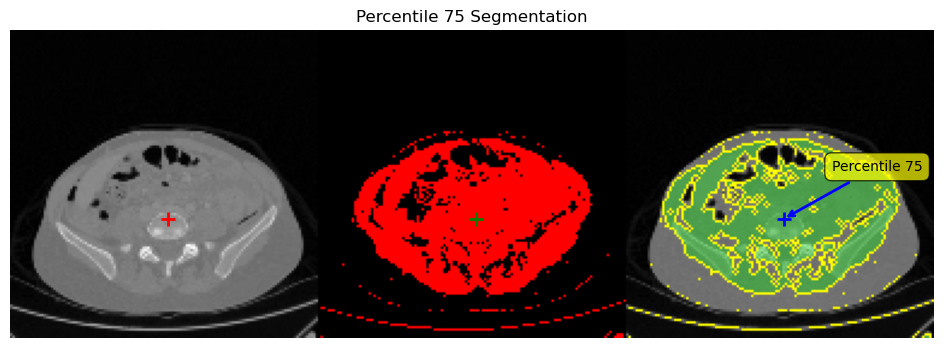

In [ ]:
image = sitk.ReadImage("./low_low_resolution.nii.gz", imageIO="NiftiImageIO")
slice_2d = image[:, :, image.GetSize()[2] // 2]

slice_2d = sitk.Cast(sitk.RescaleIntensity(slice_2d, 0, 255), sitk.sitkUInt8)

threshold_value = float(np.percentile(sitk.GetArrayViewFromImage(slice_2d), 75))
mask = sitk.BinaryThreshold(slice_2d, lowerThreshold=threshold_value, upperThreshold=255, insideValue=1, outsideValue=0)

stats = sitk.LabelShapeStatisticsImageFilter()
stats.Execute(mask)
centroid_coords_pixels = slice_2d.TransformPhysicalPointToIndex(stats.GetCentroid(1))

img_original_rgb = sitk.Compose([slice_2d] * 3)
zeros = sitk.Image(mask.GetSize(), sitk.sitkUInt8)
zeros.CopyInformation(mask)
img_mask_rgb = sitk.Compose([sitk.Cast(mask * 255, sitk.sitkUInt8), zeros, zeros])

overlay_np = sitk.GetArrayFromImage(sitk.LabelOverlay(slice_2d, mask, opacity=0.4))
overlay_np[sitk.GetArrayFromImage(sitk.LabelContour(mask)) == 1] = [255, 255, 0]

img_overlay_final = sitk.GetImageFromArray(overlay_np, isVector=True)
img_overlay_final.CopyInformation(slice_2d)

mosaic_np = sitk.GetArrayFromImage(sitk.Tile([img_original_rgb, img_mask_rgb, img_overlay_final], [3, 1]))

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(mosaic_np)
ax.set_title("Percentile 75 Segmentation")
ax.axis('off')

cx, cy = centroid_coords_pixels
width = slice_2d.GetWidth()
ax.plot(cx, cy, 'r+', markersize=10, markeredgewidth=2)
ax.plot(cx + width, cy, 'g+', markersize=10, markeredgewidth=2)
ax.plot(cx + 2 * width, cy, 'b+', markersize=10, markeredgewidth=2)

ax.annotate('Percentile 75', xy=(cx + 2 * width, cy), xytext=(cx + 2 * width + 20, cy - 20),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='blue', lw=2),
            fontsize=10, color='black')

plt.show()

### 5.3 Visualization Enhancement Conclusions

1. **Color Maps**: Different color maps serve different purposes:
   - Grayscale preserves medical imaging conventions and absolute intensity relationships
   - Perceptually uniform maps (viridis, plasma) reveal subtle variations better
   - Specialized maps (bone, hot) emphasize specific tissue types

2. **Overlays and Annotations**: Essential for clinical communication:
   - Segmentation masks highlight regions of interest
   - Contours clearly delineate boundaries
   - Annotations enable marking and labeling specific anatomical features

These visualization techniques are crucial in medical imaging for diagnosis, treatment planning, and research.

## 6. Format Transformation

In this section, we'll convert processed medical imaging data to the RAW format and discuss the advantages and disadvantages of different file formats used in medical visualization.

### 6.1 Converting to RAW Format

The RAW format stores pure pixel/voxel data without any header information. This makes it simple but requires external knowledge of dimensions and data type. We'll convert our processed image to RAW format following the naming convention: `NAME_DIMX_DIMY_DIMZ.raw`

In [5]:
(x,y,z) = image.GetSize()
sitk.WriteImage(image, "img_" + str(x) + "_" + str(y) + "_" + str(z) + ".mhd")

### 6.2 Raw format, advantages and disadvantages

A pure RAW file contains only the voxel values with no metadata, so if you save an image this way you must explicitly tell the reader its width, height, depth, data type, spacing, endianness, and layout; otherwise the file can’t be interpreted. This makes RAW very simple and fast but not portable, since every detail must be provided manually.

ITK solves this by pairing the RAW data with an MHD header, a small text file that stores all the necessary metadata so the RAW can be loaded correctly without guessing. This keeps the full fidelity and simplicity of the raw binary data while making it self-describing and usable across different tools. The downside is that you have to manage two files and it still lacks the rich clinical metadata of formats like DICOM.

# REVIEW CONCLUSION

* 9.5/10

---
⚠️​
Comment by [Carles]: 

Overall, it is a good documentation for basic functionalityes of SimpleITK:
It shows how to import, manipulate and export images using the library. It also provides insight in some methods, the conventions that sitk uses (such as using matplotlib for showing slices) and additional functionalityes like overlay and annotations. ***Seems to fulfill the requirements of the task***.

The only problems I see:
1. some missconceptions on the comments of the library (it uses numpy under the hood for example)
2. At first, A good code structure based on reusability by wrapping commands under a function. Later, a bit mixed functionalityes in a single code line (slicing, image manipulation, segmentation, annotations, plotting in a single code snipped).
3. !this is not a mistake!: The raw image export is not valid for the Medical Visualization project. In the final delivery it would be nice to provide a export with the format requested by the project.

---